<a href="https://colab.research.google.com/github/HoaiNam2k5/IOT_LAB04_NguyenHoaiNam/blob/main/IOT_LAB04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IOT LAB 04 2001230530 Nguyễn Hoài Nam**

In [1]:
import os
import getpass
import threading
import time
import socket

# Install required libraries
!pip install -q flask flask-cors pyngrok requests pandas

from flask import Flask
from flask_cors import CORS
from pyngrok import ngrok, conf
from werkzeug.serving import make_server

# Global variables to manage Flask app and ngrok tunnel
PUBLIC_URL = None
flask_thread = None
ngrok_tunnel = None
flask_server = None # To hold the werkzeug server instance

def stop_flask():
    """Stops the running Flask server and ngrok tunnel."""
    global flask_thread, ngrok_tunnel, PUBLIC_URL, flask_server

    print("\nAttempting to stop Flask server and ngrok tunnel...")

    # Close ngrok tunnel if it exists
    if ngrok_tunnel:
        try:
            print(f"Disconnecting ngrok tunnel: {ngrok_tunnel.public_url}")
            ngrok.disconnect(ngrok_tunnel.public_url)
            ngrok.kill() # Kill all ngrok processes
        except Exception as e:
            print(f"Error disconnecting ngrok: {e}")
        ngrok_tunnel = None

    # Shutdown Flask server if it exists
    if flask_server:
        try:
            print("Shutting down Flask server...")
            flask_server.shutdown()
        except Exception as e:
            print(f"Error shutting down Flask server: {e}")
        flask_server = None

    # Wait for the Flask thread to finish if it's still alive
    if flask_thread and flask_thread.is_alive():
        print("Waiting for Flask thread to terminate...")
        # Setting a short timeout, as forcefully stopping threads is not Pythonic
        flask_thread.join(timeout=1)
        if flask_thread.is_alive():
            print("Flask thread did not terminate gracefully.")
        flask_thread = None

    PUBLIC_URL = None
    print("Flask server and ngrok tunnel stopped.\n")

def run_flask_in_colab(app, port=5000):
    """Runs a Flask app in a background thread and opens an ngrok tunnel."""
    global flask_thread, ngrok_tunnel, PUBLIC_URL, flask_server

    # Ensure previous instances are stopped to prevent 'port already in use' errors
    stop_flask()

    def run_server():
        """Helper function to run the Flask app using werkzeug's make_server."""
        global flask_server
        # Use make_server to run the app, which allows for graceful shutdown
        flask_server = make_server('127.0.0.1', port, app)
        print(f"Serving Flask app on http://127.0.0.1:{port}")
        flask_server.serve_forever() # This blocks until server.shutdown() is called

    # Start Flask app in a new thread
    flask_thread = threading.Thread(target=run_server, daemon=True)
    flask_thread.start()

    # Give the server a moment to start up
    time.sleep(1)

    # Configure ngrok authtoken if not already configured
    # This prevents asking for the token on every run if it's already set
    if not conf.get_default().auth_token:
        print("\nNgrok authtoken not found. Please enter it below.")
        authtoken = getpass.getpass("Enter your ngrok authtoken: ")
        ngrok.set_auth_token(authtoken)
        print("Ngrok authtoken set.")

    # Open ngrok tunnel
    try:
        print(f"Opening ngrok tunnel for port {port}...")
        ngrok_tunnel = ngrok.connect(port)
        PUBLIC_URL = ngrok_tunnel.public_url
        print(f"Public URL: {PUBLIC_URL}")
    except Exception as e:
        print(f"Error opening ngrok tunnel: {e}")
        stop_flask() # Clean up if tunnel creation fails

    print("Flask app and ngrok tunnel are ready!")

# Example usage (uncomment and replace with your Flask app):
# app = Flask(__name__)
# CORS(app) # Enable CORS if needed

# @app.route('/')
# def hello_world():
#     return 'Hello from Colab Flask!'

# # To run your app:
# # run_flask_in_colab(app)

# # To stop your app (useful before re-running the cell or if you change your app logic):
# # stop_flask()


## Explanation for running Flask in Google Colab:

1.  **Why `app.run()` blocks in Colab:**
    When you call `app.run()` in a typical Python script, it starts a web server that continuously listens for incoming requests. This is a blocking operation, meaning the code execution will halt at that line and not proceed further until the server is stopped. In Google Colab, each cell runs sequentially. If `app.run()` is called directly, the cell would never finish executing, and you wouldn't be able to run any subsequent cells or interact with your notebook.
    To overcome this, we run the Flask application in a separate **background thread**. This allows the Colab cell to complete its execution while the Flask server continues to run in the background, listening for requests.

2.  **The role of ngrok:**
    Google Colab notebooks run on virtual machines hosted by Google. These machines typically have private IP addresses and are not directly accessible from the public internet. If you want to expose your Flask application (or any local server) running in Colab to the outside world, you need a tunneling service.
    **ngrok** creates a secure, public URL (a "tunnel") that forwards requests to your local server running in the Colab environment. This means you can share your Colab-hosted Flask application with others, or integrate it with external services that need to send requests to your app, even though it's running behind a NAT or firewall.

# **Bài 1: Sử dụng GET request lấy dữ liệu thời tiết (Open-Meteo API)**

In [2]:
import requests
import pandas as pd
from datetime import datetime

# 1. Định nghĩa danh sách các thành phố (list of dict)
cities = [
    {"name": "Hà Nội", "lat": 21.0245, "lon": 105.8412},
    {"name": "Đà Nẵng", "lat": 16.0544, "lon": 108.2022},
    {"name": "TP. Hồ Chí Minh", "lat": 10.8231, "lon": 106.6297}
]

weather_data = []
base_url = "https://api.open-meteo.com/v1/forecast"

print("--- Bắt đầu lấy dữ liệu thời tiết ---\n")

for city in cities:
    # Thiết lập các tham số cho GET request
    params = {
        "latitude": city["lat"],
        "longitude": city["lon"],
        "current": "temperature_2m,wind_speed_10m",
        "timezone": "Asia/Bangkok"
    }

    try:
        # 2. Gửi GET request tới API Open-Meteo
        response = requests.get(base_url, params=params, timeout=10)

        # In ra URL đầy đủ và status code để kiểm tra
        print(f"City: {city['name']}")
        print(f"Request URL: {response.url}")
        print(f"HTTP Status Code: {response.status_code}")

        # 3. Kiểm tra mã trạng thái HTTP
        if response.status_code != 200:
            print(f"Lỗi: API trả về mã lỗi {response.status_code}")
            continue

        # 4. Giải mã dữ liệu JSON
        data = response.json()
        current = data["current"]

        # 5. Lưu kết quả vào danh sách tạm thời
        weather_data.append({
            "City": city["name"],
            "Latitude": city["lat"],
            "Longitude": city["lon"],
            "Temperature (°C)": current["temperature_2m"],
            "Windspeed": current["wind_speed_10m"],
            "Time": current["time"]
        })

    except requests.exceptions.Timeout:
        print(f"Lỗi: Yêu cầu tới {city['name']} quá thời gian (timeout).")
    except requests.exceptions.RequestException as e:
        print(f"Lỗi kết nối tới {city['name']}: {e}")

    print("-" * 30)

# 6. Gom kết quả vào pandas DataFrame
df = pd.DataFrame(weather_data)

# 7. Hiển thị kết quả
print("\n--- Bảng kết quả (Markdown) ---")
print(df.to_markdown(index=False))

print("\n--- Bảng kết quả (Rich Display) ---")
display(df)

--- Bắt đầu lấy dữ liệu thời tiết ---

City: Hà Nội
Request URL: https://api.open-meteo.com/v1/forecast?latitude=21.0245&longitude=105.8412&current=temperature_2m%2Cwind_speed_10m&timezone=Asia%2FBangkok
HTTP Status Code: 200
------------------------------
City: Đà Nẵng
Request URL: https://api.open-meteo.com/v1/forecast?latitude=16.0544&longitude=108.2022&current=temperature_2m%2Cwind_speed_10m&timezone=Asia%2FBangkok
HTTP Status Code: 200
------------------------------
City: TP. Hồ Chí Minh
Request URL: https://api.open-meteo.com/v1/forecast?latitude=10.8231&longitude=106.6297&current=temperature_2m%2Cwind_speed_10m&timezone=Asia%2FBangkok
HTTP Status Code: 200
------------------------------

--- Bảng kết quả (Markdown) ---
| City            |   Latitude |   Longitude |   Temperature (°C) |   Windspeed | Time             |
|:----------------|-----------:|------------:|-------------------:|------------:|:-----------------|
| Hà Nội          |    21.0245 |     105.841 |               2

,City,Latitude,Longitude,Temperature (°C),Windspeed,Time
0,Hà Nội,21.0245,105.8412,24.7,3.3,2026-09-16T20:15
1,Đà Nẵng,16.0544,108.2022,26.4,8.2,2026-09-16T20:15
2,TP. Hồ Chí Minh,10.8231,106.6297,27.2,1.5,2026-09-16T20:15


# **Bài 2: Mô phỏng thiết bị IoT gửi dữ liệu HTTP POST ngẫu nhiên**

In [3]:
import requests
import time
import random
import json
import pandas as pd
from datetime import datetime

def send_data(url="https://httpbin.org/post", n=5, delay=2):
    """
    Mô phỏng thiết bị IoT gửi dữ liệu cảm biến lên server.
    - url: Endpoint nhận dữ liệu
    - n: Số lần gửi
    - delay: Thời gian chờ giữa các lần gửi (giây)
    """
    logs = []
    device_id = "ESP32_01"

    print(f"--- Bắt đầu mô phỏng thiết bị {device_id} ---\n")

    for i in range(1, n + 1):
        # 1. Tạo dữ liệu giả lập (Temperature & Humidity)
        temp = round(random.uniform(20.0, 40.0), 2)
        humi = round(random.uniform(30.0, 90.0), 2)
        timestamp = datetime.now().isoformat()

        payload = {
            "device_id": device_id,
            "temperature": temp,
            "humidity": humi,
            "timestamp": timestamp
        }

        headers = {'Content-Type': 'application/json'}

        try:
            # 2. Gửi HTTP POST với body JSON
            print(f"[Lần {i}] --> SENT: {json.dumps(payload)}")
            response = requests.post(url, json=payload, headers=headers, timeout=10)

            # 3. In log phản hồi từ server
            print(f"[Lần {i}] <-- STATUS: {response.status_code} | RESPONSE: {response.text[:100]}...")

            # Lưu dữ liệu vào log để tổng hợp
            logs.append({
                "Attempt": i,
                "Status": response.status_code,
                "Temperature": temp,
                "Humidity": humi,
                "Timestamp": timestamp
            })

        except requests.exceptions.RequestException as e:
            print(f"[Lần {i}] !!! LỖI MẠNG: {e}")
            logs.append({
                "Attempt": i,
                "Status": "Error",
                "Temperature": temp,
                "Humidity": humi,
                "Timestamp": timestamp
            })

        # 4. Chờ trước khi gửi lần tiếp theo
        if i < n:
            time.sleep(delay)

    # 5. Tổng hợp vào DataFrame
    print("\n--- Tổng hợp kết quả mô phỏng ---")
    results_df = pd.DataFrame(logs)
    display(results_df)
    return results_df

# Chạy hàm mô phỏng
df_iot = send_data()

--- Bắt đầu mô phỏng thiết bị ESP32_01 ---

[Lần 1] --> SENT: {"device_id": "ESP32_01", "temperature": 20.9, "humidity": 44.1, "timestamp": "2026-09-16T13:19:08.988644"}
[Lần 1] <-- STATUS: 200 | RESPONSE: {
  "args": {}, 
  "data": "{\"device_id\": \"ESP32_01\", \"temperature\": 20.9, \"humidity\": 44.1,...
[Lần 2] --> SENT: {"device_id": "ESP32_01", "temperature": 23.32, "humidity": 37.24, "timestamp": "2026-09-16T13:19:11.439715"}
[Lần 2] <-- STATUS: 200 | RESPONSE: {
  "args": {}, 
  "data": "{\"device_id\": \"ESP32_01\", \"temperature\": 23.32, \"humidity\": 37.2...
[Lần 3] --> SENT: {"device_id": "ESP32_01", "temperature": 36.92, "humidity": 52.86, "timestamp": "2026-09-16T13:19:13.616716"}
[Lần 3] <-- STATUS: 200 | RESPONSE: {
  "args": {}, 
  "data": "{\"device_id\": \"ESP32_01\", \"temperature\": 36.92, \"humidity\": 52.8...
[Lần 4] --> SENT: {"device_id": "ESP32_01", "temperature": 23.27, "humidity": 52.12, "timestamp": "2026-09-16T13:19:15.927328"}
[Lần 4] <-- STATUS: 200 | 

,Attempt,Status,Temperature,Humidity,Timestamp
0,1,200,20.90,44.10,2026-09-16T13:19:08.988644
1,2,200,23.32,37.24,2026-09-16T13:19:11.439715
2,3,200,36.92,52.86,2026-09-16T13:19:13.616716
3,4,200,23.27,52.12,2026-09-16T13:19:15.927328
4,5,200,28.16,68.47,2026-09-16T13:19:18.065720


# **Bài 3: IoT Mini Project - Flask Server + Ngrok lưu trữ dữ liệu**

In [8]:
from flask import Flask, request, jsonify
import pandas as pd
from datetime import datetime

# Khởi tạo Flask app và DataFrame toàn cục
app = Flask(__name__)
CORS(app)
df_sensor = pd.DataFrame(columns=["device_id", "temperature", "humidity", "timestamp", "received_at"])

@app.route('/')
def index():
    return "IoT Flask Server is running on Google Colab!"

@app.route('/data', methods=['POST'])
def receive_data():
    global df_sensor
    payload = request.get_json()

    # 1. Validate: Kiểm tra các trường bắt buộc
    required_fields = ["device_id", "temperature", "humidity", "timestamp"]
    missing = [f for f in required_fields if f not in payload]

    if missing:
        return jsonify({"status": "error", "message": f"Missing fields: {missing}"}), 400

    # 2. Thêm dữ liệu vào DataFrame toàn cục
    new_row = payload.copy()
    new_row['received_at'] = datetime.now().isoformat()
    df_sensor = pd.concat([df_sensor, pd.DataFrame([new_row])], ignore_index=True)

    # 3. Phản hồi thành công
    return jsonify({
        "status": "success",
        "received": payload,
        "total_records": len(df_sensor)
    }), 200

@app.route('/data', methods=['GET'])
def get_data():
    return jsonify(df_sensor.to_dict(orient="records"))

# Chạy server sử dụng hàm tiện ích từ Phần 0
run_flask_in_colab(app)


Attempting to stop Flask server and ngrok tunnel...
Shutting down Flask server...
Flask server and ngrok tunnel stopped.

Serving Flask app on http://127.0.0.1:5000

Ngrok authtoken not found. Please enter it below.
Enter your ngrok authtoken: ··········
Ngrok authtoken set.
Opening ngrok tunnel for port 5000...
Public URL: https://magical-error-imprint.ngrok-free.dev
Flask app and ngrok tunnel are ready!


In [9]:
# Đảm bảo server đã có URL công khai trước khi chạy client
if PUBLIC_URL:
    print(f"Target URL: {PUBLIC_URL}/data")
    # Sử dụng lại hàm send_data từ cell trước đó, trỏ tới endpoint mới
    df_client_results = send_data(url=f"{PUBLIC_URL}/data", n=5, delay=2)
else:
    print("Lỗi: PUBLIC_URL chưa được thiết lập. Hãy kiểm tra server ở cell trên.")

/tmp/ipykernel_3076/879456547.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sensor = pd.concat([df_sensor, pd.DataFrame([new_row])], ignore_index=True)
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:27:59] "POST /data HTTP/1.1" 200 -


Target URL: https://magical-error-imprint.ngrok-free.dev/data
--- Bắt đầu mô phỏng thiết bị ESP32_01 ---

[Lần 1] --> SENT: {"device_id": "ESP32_01", "temperature": 28.38, "humidity": 67.88, "timestamp": "2026-09-16T13:27:58.924156"}
[Lần 1] <-- STATUS: 200 | RESPONSE: {"received":{"device_id":"ESP32_01","humidity":67.88,"temperature":28.38,"timestamp":"2026-09-16T13:...


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:28:01] "POST /data HTTP/1.1" 200 -


[Lần 2] --> SENT: {"device_id": "ESP32_01", "temperature": 27.88, "humidity": 75.41, "timestamp": "2026-09-16T13:28:01.097846"}
[Lần 2] <-- STATUS: 200 | RESPONSE: {"received":{"device_id":"ESP32_01","humidity":75.41,"temperature":27.88,"timestamp":"2026-09-16T13:...


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:28:03] "POST /data HTTP/1.1" 200 -


...

INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:28:05] "POST /data HTTP/1.1" 200 -


[Lần 4] --> SENT: {"device_id": "ESP32_01", "temperature": 21.96, "humidity": 67.79, "timestamp": "2026-09-16T13:28:05.459310"}
[Lần 4] <-- STATUS: 200 | RESPONSE: {"received":{"device_id":"ESP32_01","humidity":67.79,"temperature":21.96,"timestamp":"2026-09-16T13:...


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:28:07] "POST /data HTTP/1.1" 200 -


[Lần 5] --> SENT: {"device_id": "ESP32_01", "temperature": 39.59, "humidity": 37.37, "timestamp": "2026-09-16T13:28:07.621804"}
[Lần 5] <-- STATUS: 200 | RESPONSE: {"received":{"device_id":"ESP32_01","humidity":37.37,"temperature":39.59,"timestamp":"2026-09-16T13:...

--- Tổng hợp kết quả mô phỏng ---


,Attempt,Status,Temperature,Humidity,Timestamp
0,1,200,28.38,67.88,2026-09-16T13:27:58.924156
1,2,200,27.88,75.41,2026-09-16T13:28:01.097846
2,3,200,24.08,39.30,2026-09-16T13:28:03.277804
3,4,200,21.96,67.79,2026-09-16T13:28:05.459310
4,5,200,39.59,37.37,2026-09-16T13:28:07.621804


--- Dữ liệu trong df_sensor trên Server ---


,device_id,temperature,humidity,timestamp,received_at
0,ESP32_01,28.38,67.88,2026-09-16T13:27:58.924156,2026-09-16T13:27:59.060637
1,ESP32_01,27.88,75.41,2026-09-16T13:28:01.097846,2026-09-16T13:28:01.233805
2,ESP32_01,24.08,39.30,2026-09-16T13:28:03.277804,2026-09-16T13:28:03.411262
3,ESP32_01,21.96,67.79,2026-09-16T13:28:05.459310,2026-09-16T13:28:05.584007
4,ESP32_01,39.59,37.37,2026-09-16T13:28:07.621804,2026-09-16T13:28:07.745483


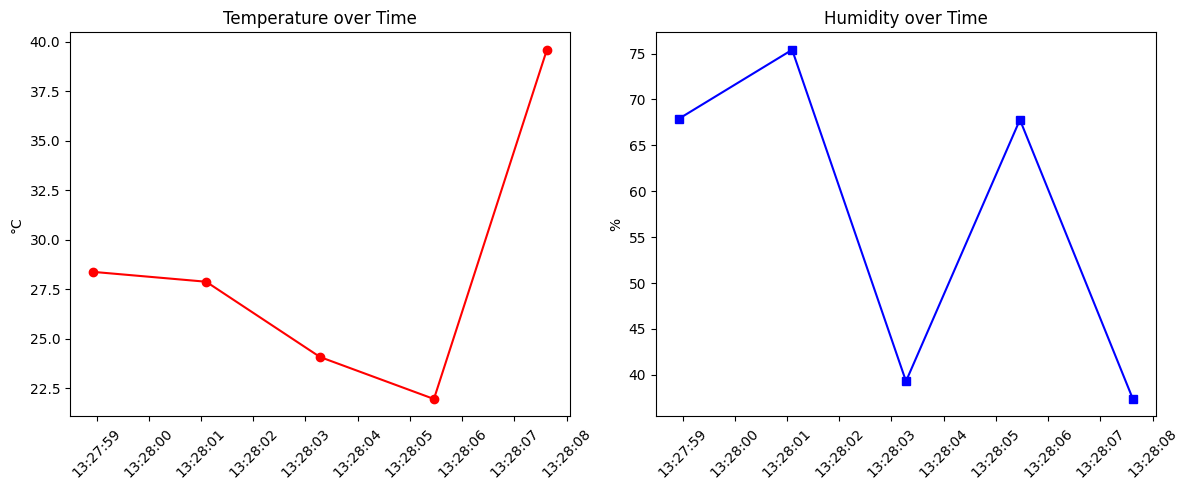

In [10]:
import matplotlib.pyplot as plt

# 1. Hiển thị DataFrame toàn cục thu thập được trên Server
print("--- Dữ liệu trong df_sensor trên Server ---")
display(df_sensor)

# 2. Vẽ biểu đồ nếu có dữ liệu
if not df_sensor.empty:
    df_sensor['timestamp_dt'] = pd.to_datetime(df_sensor['timestamp'])
    df_sensor = df_sensor.sort_values('timestamp_dt')

    plt.figure(figsize=(12, 5))

    # Biểu đồ nhiệt độ
    plt.subplot(1, 2, 1)
    plt.plot(df_sensor['timestamp_dt'], df_sensor['temperature'], marker='o', color='red')
    plt.title('Temperature over Time')
    plt.xticks(rotation=45)
    plt.ylabel('°C')

    # Biểu đồ độ ẩm
    plt.subplot(1, 2, 2)
    plt.plot(df_sensor['timestamp_dt'], df_sensor['humidity'], marker='s', color='blue')
    plt.title('Humidity over Time')
    plt.xticks(rotation=45)
    plt.ylabel('%')

    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu để vẽ biểu đồ.")

### Giải thích luồng hoạt động (IoT Mini Project):
1. **Client (IoT Device)**: Giả lập ESP32, tạo gói tin JSON và gửi qua phương thức **POST**.
2. **Ngrok**: Nhận request từ internet vào Public URL và chuyển tiếp (tunnel) tới cổng 5000 cục bộ trong Colab.
3. **Flask Server**: Nhận request tại endpoint `/data`, kiểm tra tính hợp lệ (Validation), và lưu vào biến toàn cục `df_sensor`.
4. **DataFrame & Response**: Dữ liệu được tích lũy để xử lý/phân tích, và server gửi phản hồi **JSON** (200 OK hoặc 400 Bad Request) về cho Client để xác nhận.

# **Bài 4: Gửi nhiều thông số cảm biến và Cảnh báo ngưỡng (Threshold Warning)**

In [11]:
from flask import Flask, request, jsonify
from datetime import datetime

app_warning = Flask(__name__)
CORS(app_warning)

# Cấu hình ngưỡng tập trung để dễ chỉnh sửa
THRESHOLDS = {
    "temperature": 35,
    "humidity": 40,
    "light": 200
}

@app_warning.route('/sensor', methods=['POST'])
def monitor_sensor():
    data = request.get_json()

    # 1. Validate Input (Kiểm tra sự tồn tại và kiểu dữ liệu)
    required = ["temperature", "humidity", "light"]
    if not data or not all(k in data for k in required):
        return jsonify({"status": "error", "message": "Thiếu trường dữ liệu"}), 400

    if not all(isinstance(data[k], (int, float)) for k in required):
        return jsonify({"status": "error", "message": "Sai kiểu dữ liệu (phải là number)"}), 400

    # 2. Xử lý logic cảnh báo
    alerts = []
    if data["temperature"] > THRESHOLDS["temperature"]:
        alerts.append("HIGH_TEMPERATURE")
    if data["humidity"] < THRESHOLDS["humidity"]:
        alerts.append("LOW_HUMIDITY")
    if data["light"] < THRESHOLDS["light"]:
        alerts.append("LOW_LIGHT")

    # 3. Xây dựng Response
    response = {
        "status": "WARNING" if alerts else "OK",
        "alerts": alerts,
        "data": data,
        "timestamp": datetime.now().isoformat()
    }

    return jsonify(response), 200

# Dùng hàm tiện ích từ Phần 0 để chạy server
run_flask_in_colab(app_warning)


Attempting to stop Flask server and ngrok tunnel...
Disconnecting ngrok tunnel: https://magical-error-imprint.ngrok-free.dev
Shutting down Flask server...
Flask server and ngrok tunnel stopped.

Serving Flask app on http://127.0.0.1:5000

Ngrok authtoken not found. Please enter it below.
Enter your ngrok authtoken: ··········
Ngrok authtoken set.
Opening ngrok tunnel for port 5000...
Public URL: https://magical-error-imprint.ngrok-free.dev
Flask app and ngrok tunnel are ready!


In [12]:
import requests
import pandas as pd

# Dữ liệu thử nghiệm
test_cases = [
    {"name": "Bình thường", "payload": {"temperature": 28, "humidity": 60, "light": 500}, "expected": "OK (No alerts)"},
    {"name": "Một cảnh báo", "payload": {"temperature": 38, "humidity": 55, "light": 400}, "expected": "HIGH_TEMPERATURE"},
    {"name": "Ba cảnh báo", "payload": {"temperature": 39, "humidity": 35, "light": 100}, "expected": "3 ALERTS"}
]

comparison_results = []

if PUBLIC_URL:
    url = f"{PUBLIC_URL}/sensor"
    print(f"Target URL: {url}\n")

    for case in test_cases:
        try:
            res = requests.post(url, json=case["payload"], timeout=5)
            server_res = res.json()

            actual = f"{server_res['status']}: {', '.join(server_res['alerts']) if server_res['alerts'] else 'None'}"

            comparison_results.append({
                "Kịch bản": case["name"],
                "Input": case["payload"],
                "Mong đợi": case["expected"],
                "Thực tế": actual
            })
            print(f"Done: {case['name']}")
        except Exception as e:
            print(f"Lỗi khi test {case['name']}: {e}")

    # Hiển thị bảng so sánh
    df_compare = pd.DataFrame(comparison_results)
    display(df_compare)
else:
    print("Vui lòng đợi Server khởi tạo PUBLIC_URL")

INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:35:08] "POST /sensor HTTP/1.1" 200 -


Target URL: https://magical-error-imprint.ngrok-free.dev/sensor



INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:35:08] "POST /sensor HTTP/1.1" 200 -


Done: Bình thường
Done: Một cảnh báo


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:35:08] "POST /sensor HTTP/1.1" 200 -


Done: Ba cảnh báo


,Kịch bản,Input,Mong đợi,Thực tế
0,Bình thường,"{'temperature': 28, 'humidity': 60, 'light': 500}",OK (No alerts),OK: None
1,Một cảnh báo,"{'temperature': 38, 'humidity': 55, 'light': 400}",HIGH_TEMPERATURE,WARNING: HIGH_TEMPERATURE
2,Ba cảnh báo,"{'temperature': 39, 'humidity': 35, 'light': 100}",3 ALERTS,"WARNING: HIGH_TEMPERATURE, LOW_HUMIDITY, LOW_L..."


### Giải thích luồng Request/Response:

1.  **Client tạo Payload**: Phía Client (thiết bị IoT hoặc app mô phỏng) đóng gói các giá trị cảm biến vào một đối tượng JSON.
2.  **HTTP POST + Header**: Client gửi request qua internet kèm header `Content-Type: application/json` để Server biết cách đọc dữ liệu.
3.  **Flask Route nhận & Parse**: Server Flask bắt được request tại đường dẫn `/sensor`. Hàm `request.get_json()` chuyển đổi chuỗi JSON thô thành Dictionary trong Python.
4.  **Áp dụng Rule**: Server so sánh các giá trị trong dictionary với biến `THRESHOLDS` để xác định trạng thái `OK` hoặc `WARNING`.
5.  **Build Response JSON**: Một dictionary mới được tạo ra chứa kết quả xử lý và được hàm `jsonify()` chuyển ngược lại thành chuỗi JSON.
6.  **HTTP Status**: Server trả về mã **200 OK** (thành công) hoặc **400 Bad Request** (nếu dữ liệu sai định dạng).
7.  **Client Parse & In**: Client nhận được phản hồi, giải mã JSON và trình bày lên bảng so sánh.

# **Bài 5: Server gửi lệnh điều khiển thiết bị (Actuator Control Logic)**

In [13]:
from flask import Flask, request, jsonify
import pandas as pd
from datetime import datetime

app_control = Flask(__name__)
CORS(app_control)

# Lịch sử điều khiển toàn cục
control_history = []

@app_control.route('/data', methods=['POST'])
def control_logic():
    global control_history
    data = request.get_json()

    # 1. Kiểm tra đầu vào
    required = ["device_id", "temperature", "humidity"]
    if not data or not all(k in data for k in required):
        return jsonify({"status": "error", "message": "Dữ liệu không đầy đủ"}), 400

    temp = data["temperature"]
    humi = data["humidity"]

    # 2. Logic điều khiển & Giải thích (Reasoning)
    commands = {}
    reasons = []

    if temp > 30:
        commands["fan"] = "FAN_ON"
        reasons.append(f"temperature {temp} > 30")
    else:
        commands["fan"] = "FAN_OFF"
        reasons.append(f"temperature {temp} <= 30")

    if humi < 45:
        commands["pump"] = "PUMP_ON"
        reasons.append(f"humidity {humi} < 45")
    else:
        commands["pump"] = "PUMP_OFF"
        reasons.append(f"humidity {humi} >= 45")

    # 3. Lưu lịch sử
    log_entry = {
        "device_id": data["device_id"],
        "temperature": temp,
        "humidity": humi,
        "fan_cmd": commands["fan"],
        "pump_cmd": commands["pump"],
        "timestamp": datetime.now().strftime("%H:%M:%S")
    }
    control_history.append(log_entry)

    return jsonify({
        "status": "success",
        "commands": commands,
        "reasons": reasons,
        "data": data
    }), 200

# Khởi chạy server mới
run_flask_in_colab(app_control)


Attempting to stop Flask server and ngrok tunnel...
Disconnecting ngrok tunnel: https://magical-error-imprint.ngrok-free.dev
Shutting down Flask server...
Flask server and ngrok tunnel stopped.

Serving Flask app on http://127.0.0.1:5000

Ngrok authtoken not found. Please enter it below.
Enter your ngrok authtoken: ··········
Ngrok authtoken set.
Opening ngrok tunnel for port 5000...
Public URL: https://magical-error-imprint.ngrok-free.dev
Flask app and ngrok tunnel are ready!


In [14]:
import requests
import time
import random
import pandas as pd

def simulate_iot_control(url, iterations=5):
    # Trạng thái hiện tại của thiết bị trên Client
    device_state = {"fan": None, "pump": None}

    print(f"--- Bắt đầu điều khiển IoT tại: {url} ---\n")

    for i in range(iterations):
        # Tạo dữ liệu ngẫu nhiên
        temp = round(random.uniform(25.0, 40.0), 1)
        humi = round(random.uniform(30.0, 70.0), 1)

        payload = {
            "device_id": "SMART_GARDEN_01",
            "temperature": temp,
            "humidity": humi
        }

        try:
            res = requests.post(url, json=payload, timeout=5)
            if res.status_code == 200:
                result = res.json()
                cmds = result["commands"]

                print(f"[Lần {i+1}] Dữ liệu gửi: Temp={temp}°C, Humi={humi}%")

                # Kiểm tra thay đổi trạng thái Quạt
                if cmds["fan"] != device_state["fan"]:
                    action = "BẬT QUẠT" if cmds["fan"] == "FAN_ON" else "TẮT QUẠT"
                    print(f"  >>> CHUYỂN TRẠNG THÁI: {action} (Lý do: {result['reasons'][0]})")
                    device_state["fan"] = cmds["fan"]

                # Kiểm tra thay đổi trạng thái Bơm
                if cmds["pump"] != device_state["pump"]:
                    action = "BẬT BƠM" if cmds["pump"] == "PUMP_ON" else "TẮT BƠM"
                    print(f"  >>> CHUYỂN TRẠNG THÁI: {action} (Lý do: {result['reasons'][1]})")
                    device_state["pump"] = cmds["pump"]
            else:
                print(f"  !!! Lỗi Server: {res.status_code}")
        except Exception as e:
            print(f"  !!! Lỗi kết nối: {e}")

        time.sleep(2)

    # Hiển thị bảng lịch sử từ Server
    print("\n--- Bảng lịch sử điều khiển hệ thống ---")
    df_history = pd.DataFrame(control_history)
    display(df_history)

if PUBLIC_URL:
    simulate_iot_control(f"{PUBLIC_URL}/data")

INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:39:33] "POST /data HTTP/1.1" 200 -


--- Bắt đầu điều khiển IoT tại: https://magical-error-imprint.ngrok-free.dev/data ---

[Lần 1] Dữ liệu gửi: Temp=38.6°C, Humi=32.2%
  >>> CHUYỂN TRẠNG THÁI: BẬT QUẠT (Lý do: temperature 38.6 > 30)
  >>> CHUYỂN TRẠNG THÁI: BẬT BƠM (Lý do: humidity 32.2 < 45)


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:39:35] "POST /data HTTP/1.1" 200 -


[Lần 2] Dữ liệu gửi: Temp=26.9°C, Humi=38.2%
  >>> CHUYỂN TRẠNG THÁI: TẮT QUẠT (Lý do: temperature 26.9 <= 30)


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:39:37] "POST /data HTTP/1.1" 200 -


...

INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:39:40] "POST /data HTTP/1.1" 200 -


[Lần 4] Dữ liệu gửi: Temp=34.6°C, Humi=50.4%
  >>> CHUYỂN TRẠNG THÁI: BẬT QUẠT (Lý do: temperature 34.6 > 30)
  >>> CHUYỂN TRẠNG THÁI: TẮT BƠM (Lý do: humidity 50.4 >= 45)


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:39:41] "GET / HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:39:42] "POST /data HTTP/1.1" 200 -


[Lần 5] Dữ liệu gửi: Temp=36.7°C, Humi=50.1%

--- Bảng lịch sử điều khiển hệ thống ---


,device_id,temperature,humidity,fan_cmd,pump_cmd,timestamp
0,SMART_GARDEN_01,38.6,32.2,FAN_ON,PUMP_ON,13:39:33
1,SMART_GARDEN_01,26.9,38.2,FAN_OFF,PUMP_ON,13:39:35
2,SMART_GARDEN_01,26.5,39.7,FAN_OFF,PUMP_ON,13:39:37
3,SMART_GARDEN_01,34.6,50.4,FAN_ON,PUMP_OFF,13:39:40
4,SMART_GARDEN_01,36.7,50.1,FAN_ON,PUMP_OFF,13:39:42


# **Bài 6: Quản lý nhiều thiết bị IoT (Multi-device Management & Visualization)**

In [15]:
from flask import Flask, request, jsonify
import pandas as pd
from datetime import datetime
import threading

app_iot = Flask(__name__)
CORS(app_iot)

# Khởi tạo tài nguyên toàn cục và Lock
devices_state = {}  # {device_id: {temp, humi, last_update}}
df_history = pd.DataFrame(columns=["device_id", "temperature", "humidity", "timestamp"])
data_lock = threading.Lock()

@app_iot.route('/data', methods=['POST'])
def update_sensor():
    global df_history, devices_state
    data = request.get_json()

    if not data or "device_id" not in data:
        return jsonify({"status": "error", "message": "Missing device_id"}), 400

    d_id = data["device_id"]
    temp = data.get("temperature", 0)
    humi = data.get("humidity", 0)
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Sử dụng Lock để tránh race condition khi ghi dữ liệu
    with data_lock:
        # Cập nhật trạng thái mới nhất
        devices_state[d_id] = {
            "temperature": temp,
            "humidity": humi,
            "last_update": now
        }

        # Ghi vào lịch sử
        new_entry = pd.DataFrame([{
            "device_id": d_id,
            "temperature": temp,
            "humidity": humi,
            "timestamp": datetime.now() # Dùng kiểu datetime để vẽ đồ thị
        }])
        df_history = pd.concat([df_history, new_entry], ignore_index=True)

    return jsonify({
        "status": "success",
        "device_id": d_id,
        "total_devices": len(devices_state)
    }), 200

@app_iot.route('/devices', methods=['GET'])
def get_all_devices():
    return jsonify(devices_state), 200

@app_iot.route('/devices/<device_id>', methods=['GET'])
def get_one_device(device_id):
    state = devices_state.get(device_id)
    if state:
        return jsonify(state), 200
    return jsonify({"error": "Device not found"}), 404

# Chạy Server
run_flask_in_colab(app_iot)


Attempting to stop Flask server and ngrok tunnel...
Disconnecting ngrok tunnel: https://magical-error-imprint.ngrok-free.dev
Shutting down Flask server...
Flask server and ngrok tunnel stopped.

Serving Flask app on http://127.0.0.1:5000

Ngrok authtoken not found. Please enter it below.
Enter your ngrok authtoken: ··········
Ngrok authtoken set.
Opening ngrok tunnel for port 5000...
Public URL: https://magical-error-imprint.ngrok-free.dev
Flask app and ngrok tunnel are ready!


/tmp/ipykernel_3076/2664776697.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_history = pd.concat([df_history, new_entry], ignore_index=True)
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:55] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:55] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:55] "POST /data HTTP/1.1" 200 -


--- Đang gửi dữ liệu song song từ 3 thiết bị ---


INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:56] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:56] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:56] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:57] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:57] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:57] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:58] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:58] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:58] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:59] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:59] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:42:59] "POST /data HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/Sep/2026 13:43:00] "


--- Trạng thái mới nhất của các thiết bị ---


,device_id,humidity,last_update,temperature
0,ESP32_01,43.2,2026-09-16 13:42:59,27.8
1,ESP32_02,42.8,2026-09-16 13:42:59,30.7
2,ESP32_03,50.5,2026-09-16 13:42:59,41.0


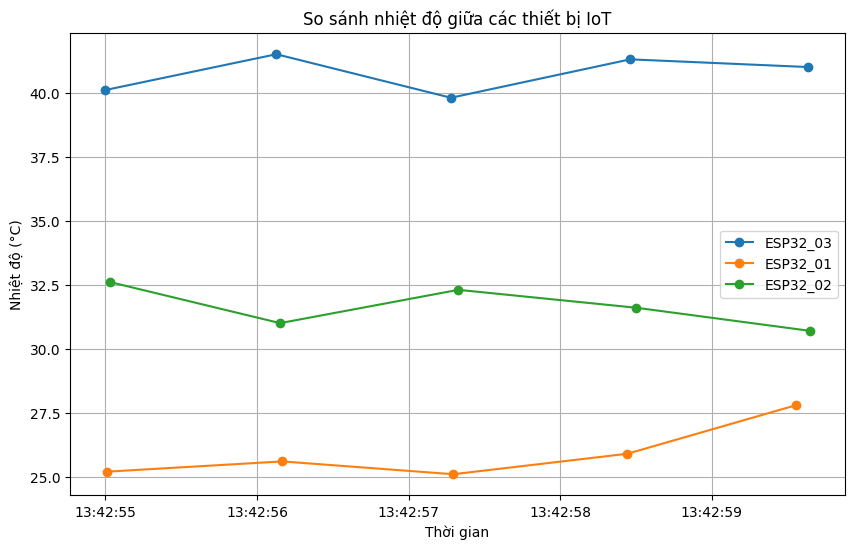

In [16]:
import requests
import time
import random
import threading
import matplotlib.pyplot as plt

def device_simulator(d_id, temp_range, url, n=5):
    for i in range(n):
        payload = {
            "device_id": d_id,
            "temperature": round(random.uniform(*temp_range), 1),
            "humidity": round(random.uniform(40, 60), 1)
        }
        try:
            requests.post(url, json=payload, timeout=5)
        except:
            pass
        time.sleep(1)

if PUBLIC_URL:
    url = f"{PUBLIC_URL}/data"
    threads = []

    # Cấu hình 3 thiết bị với dải nhiệt độ khác nhau
    configs = [
        ("ESP32_01", (25, 28)),
        ("ESP32_02", (30, 33)),
        ("ESP32_03", (37, 42))  # Thiết bị 3 nóng hơn
    ]

    print("--- Đang gửi dữ liệu song song từ 3 thiết bị ---")
    for d_id, t_range in configs:
        t = threading.Thread(target=device_simulator, args=(d_id, t_range, url))
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    # 1. Gọi GET /devices và in bảng trạng thái
    res = requests.get(f"{PUBLIC_URL}/devices")
    df_current = pd.DataFrame.from_dict(res.json(), orient='index').reset_index()
    df_current.rename(columns={'index': 'device_id'}, inplace=True)
    print("\n--- Trạng thái mới nhất của các thiết bị ---")
    display(df_current)

    # 2. Vẽ biểu đồ từ df_history
    plt.figure(figsize=(10, 6))
    for d_id in df_history['device_id'].unique():
        subset = df_history[df_history['device_id'] == d_id]
        plt.plot(subset['timestamp'], subset['temperature'], label=d_id, marker='o')

    plt.title("So sánh nhiệt độ giữa các thiết bị IoT")
    plt.xlabel("Thời gian")
    plt.ylabel("Nhiệt độ (°C)")
    plt.legend()
    plt.grid(True)
    plt.show()